In [1]:
# loading the Libaries 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import fetch_openml

mnist=fetch_openml('mnist_784', as_frame=False)

x = mnist.data
y = mnist.target

print(x.shape)
print(y.shape)

(70000, 784)
(70000,)


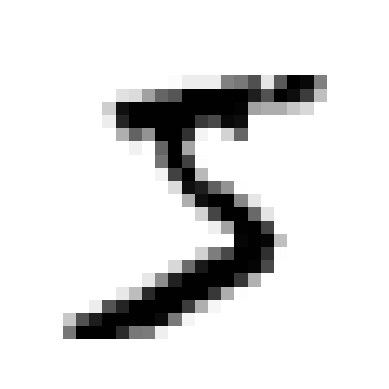

In [3]:
def plot_image(image):
    img = image.reshape(28, 28)
    plt.imshow(img, cmap='binary')
    plt.axis('off')

img = x[0]
plot_image(img)
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier

x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, test_size=10000, random_state=42)
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

sgd = SGDClassifier()
sgd.fit(x_train, y_train_5)

,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if th

In [5]:
print(sgd.predict([img]))

[ True]


In [6]:
# evaluation using cross validation

from sklearn.model_selection import cross_val_score

sgd_val_score = cross_val_score(sgd, x_train, y_train_5, cv=3, scoring='accuracy')
sgd_val_score

array([0.95225, 0.952  , 0.9589 ])

In [7]:
from sklearn.dummy import DummyClassifier

dc =  DummyClassifier()
dc.fit(x_train, y_train_5)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'prior'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.91,0.09]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[bool](2,)","[False, True]"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,784
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


In [8]:
dc_val_score = cross_val_score(dc, x_train, y_train_5, cv=3, scoring='accuracy')
dc_val_score

array([0.90985, 0.9098 , 0.9098 ])

In [9]:
from sklearn.model_selection import cross_val_predict

y_pred = cross_val_predict(sgd, x_train, y_train_5, cv=3)
y_pred

array([False, False, False, ..., False, False, False], shape=(60000,))

In [10]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train_5, y_pred)
cm

array([[53178,  1411],
       [ 1400,  4011]])

In [11]:
from sklearn.metrics import recall_score, precision_score

pred_score = precision_score(y_train_5, y_pred)
rec_score = recall_score(y_train_5, y_pred)

print('Precision Score:', pred_score)
print('Recall Score:', rec_score)

Precision Score: 0.7397639247510144
Recall Score: 0.741267787839586


In [12]:
from sklearn.metrics import f1_score

f1 = f1_score(y_train_5, y_pred)
print(f1)

0.7405150927720853


In [14]:
y_score = sgd.decision_function([img])
y_score

array([1372.558436])

In [15]:
threshold = 1500 
y_threshold_set = (y_score > threshold)
y_threshold_set

array([False])

In [16]:
y_scores = cross_val_predict(sgd, x_train, y_train_5, cv=3, method='decision_function')
y_scores

array([-24920.94371016, -10973.78094204, -13623.28248523, ...,
       -11329.50185166,  -9584.89732238,  -5920.69251026], shape=(60000,))

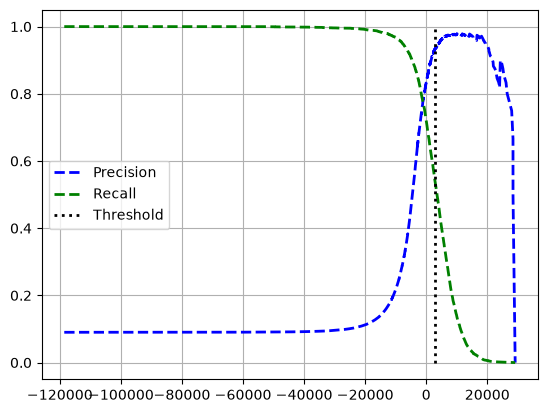

In [18]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

plt.plot(thresholds, precisions[:-1], 'b--', label='Precision', linewidth=2)
plt.plot(thresholds, recalls[:-1], 'g--', label='Recall', linewidth=2)
plt.vlines(3000, 0, 1.0, 'k', 'dotted', label='Threshold', linewidth=2)

plt.legend()
plt.grid()
plt.show()

In [19]:
ind_90_pred = (precisions >=0.90).argmax()
threshold_for_90 = thresholds[ind_90_pred]
threshold_for_90

np.float64(1623.226662686666)

In [ ]:
y_train_pred = (y_scores >= )